In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from itertools import chain

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

In [18]:
DATA_PATH = "../../data/raw/evaluation-3-20.csv"

# Load and lightly clean
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Sex"] = df["Sex"].astype(str).str.upper().str.strip()
df["Department"] = df["Department"].astype(str).str.strip()

category_map = {
    "F": ["F1", "F2", "F3"],
    "P": ["P1", "P2", "P3"],
    "I": ["I1", "I2", "I3"],
    "M": ["M1", "M2", "M3"],
    "C": ["C1", "C2", "C3"],
}
item_cols = list(chain.from_iterable(category_map.values()))

for cat, cols in category_map.items():
    df[f"{cat}_total"] = df[cols].sum(axis=1)

df["overall_total"] = df[[f"{cat}_total" for cat in category_map]].sum(axis=1)
df["overall_avg"] = df["overall_total"] / len(item_cols)

comment_cols = ["Comment #1", "Comment #2"]
df["comments_combined"] = (
    df[comment_cols]
    .fillna("na")
    .astype(str)
    .apply(lambda row: " ".join(part for part in row if part.lower() != "na"), axis=1)
)

In [19]:
print("Rows, columns:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())

display(df.head())
display(df.describe(include="all"))

Rows, columns: (56, 30)

Missing values per column:
 Name                 0
Age                  0
Sex                  0
Occupation           0
F1                   0
F2                   0
F3                   0
P1                   0
P2                   0
P3                   0
I1                   0
I2                   0
I3                   0
M1                   0
M2                   0
M3                   0
C1                   0
C2                   0
C3                   0
Comment #1           0
Comment #2           0
Department           0
F_total              0
P_total              0
I_total              0
M_total              0
C_total              0
overall_total        0
overall_avg          0
comments_combined    0
dtype: int64


,Name,Age,Sex,Occupation,F1,F2,F3,P1,P2,P3,...,Comment #2,Department,F_total,P_total,I_total,M_total,C_total,overall_total,overall_avg,comments_combined
0,M LIgad,25,F,CLA,5,5,5,5,5,5,...,na,IT,15,15,14,15,15,74,4.933333,
1,Jacob,24,M,ITSO,5,5,5,5,5,5,...,na,IT,15,15,15,14,15,74,4.933333,
2,S Coral,25,M,CLA,4,3,5,4,4,5,...,na,IT,12,13,13,13,13,64,4.266667,
3,R Lagdaan,24,M,CLA,5,5,5,5,5,5,...,na,IT,15,15,15,15,15,75,5.000000,
4,MJ Cuady,23,M,fullstack dev,5,5,5,5,5,5,...,more ui consistentcy,IT,15,15,15,15,15,75,5.000000,more ui consistentcy


,Name,Age,Sex,Occupation,F1,F2,F3,P1,P2,P3,...,Comment #2,Department,F_total,P_total,I_total,M_total,C_total,overall_total,overall_avg,comments_combined
count,56,56.000000,56,56,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,...,56,56,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56
unique,56,NaN,2,28,NaN,NaN,NaN,NaN,NaN,NaN,...,19,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21
top,M LIgad,NaN,F,student,NaN,NaN,NaN,NaN,NaN,NaN,...,na,GU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
freq,1,NaN,42,12,NaN,NaN,NaN,NaN,NaN,NaN,...,36,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34
mean,NaN,29.892857,NaN,NaN,4.714286,4.678571,4.642857,4.767857,4.750000,4.821429,...,NaN,NaN,14.035714,14.339286,14.160714,14.107143,14.250000,70.892857,4.726190,NaN
std,NaN,9.623227,NaN,NaN,0.494121,0.606245,0.553619,0.426021,0.436931,0.386459,...,NaN,NaN,1.249935,0.995933,1.187462,1.302844,1.082925,4.856780,0.323785,NaN
min,NaN,18.000000,NaN,NaN,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,...,NaN,NaN,9.000000,12.000000,11.000000,9.000000,12.000000,54.000000,3.600000,NaN
25%,NaN,23.000000,NaN,NaN,4.000000,4.750000,4.000000,5.000000,4.750000,5.000000,...,NaN,NaN,13.000000,14.000000,13.000000,14.000000,14.000000,68.750000,4.583333,NaN
50%,NaN,26.000000,NaN,NaN,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,NaN,NaN,14.500000,15.000000,15.000000,15.000000,15.000000,73.000000,4.866667,NaN
75%,NaN,35.000000,NaN,NaN,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,NaN,NaN,15.000000,15.000000,15.000000,15.000000,15.000000,75.000000,5.000000,NaN


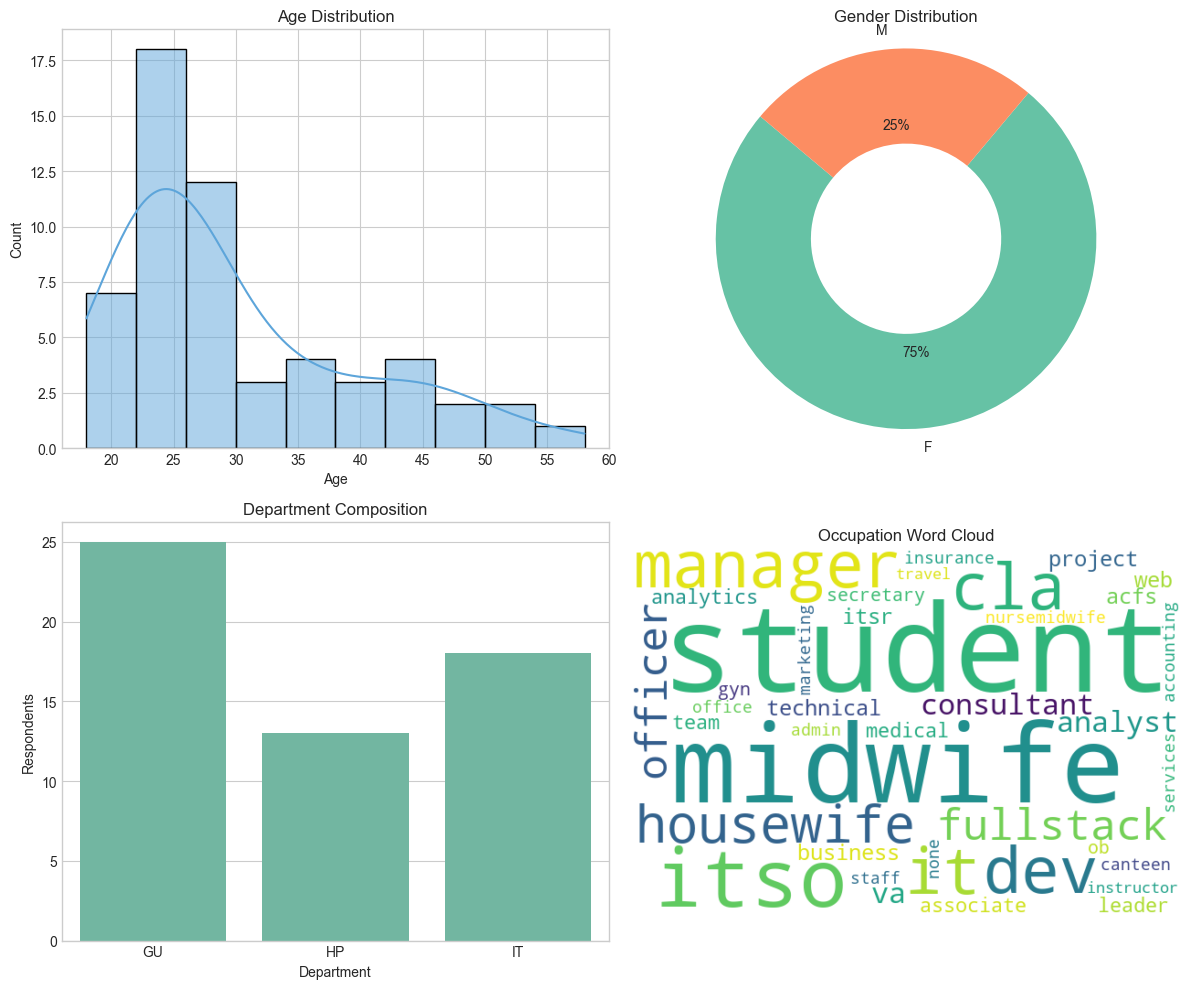

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Age distribution
sns.histplot(df["Age"].dropna(), bins=10, kde=True, ax=axes[0], color="#5DA5DA")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Gender distribution (donut)
sex_counts = df["Sex"].value_counts()
axes[1].pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.0f%%",
    startangle=140,
    wedgeprops=dict(width=0.5),
)
axes[1].set_title("Gender Distribution")
axes[1].axis("equal")

# Department composition
dept_counts = df["Department"].value_counts().sort_index()
sns.barplot(x=dept_counts.index, y=dept_counts.values, ax=axes[2])
axes[2].set_title("Department Composition")
axes[2].set_ylabel("Respondents")
axes[2].set_xlabel("Department")

# Occupation word frequencies (word cloud if available, else top terms bar)
occupations = df["Occupation"].fillna("").astype(str).str.lower()
words = (
    occupations.str.replace(r"[^a-zA-Z\s]", "", regex=True)
    .str.split()
    .explode()
)
stopwords = {"and", "the", "of", "for", "to", "a", "an", "in"}
words = words[~words.isin(stopwords)]
word_counts = Counter(words.dropna())

if WORDCLOUD_AVAILABLE and word_counts:
    wc = WordCloud(width=600, height=400, background_color="white")
    wc.generate_from_frequencies(word_counts)
    axes[3].imshow(wc, interpolation="bilinear")
    axes[3].axis("off")
    axes[3].set_title("Occupation Word Cloud")
else:
    top_terms = word_counts.most_common(10)
    if top_terms:
        terms, counts = zip(*top_terms)
        sns.barplot(x=list(counts), y=list(terms), ax=axes[3])
        axes[3].set_title("Top Occupation Terms")
        axes[3].set_xlabel("Count")
    else:
        axes[3].text(0.5, 0.5, "No occupation text", ha="center")
        axes[3].axis("off")

plt.tight_layout()
plt.show()

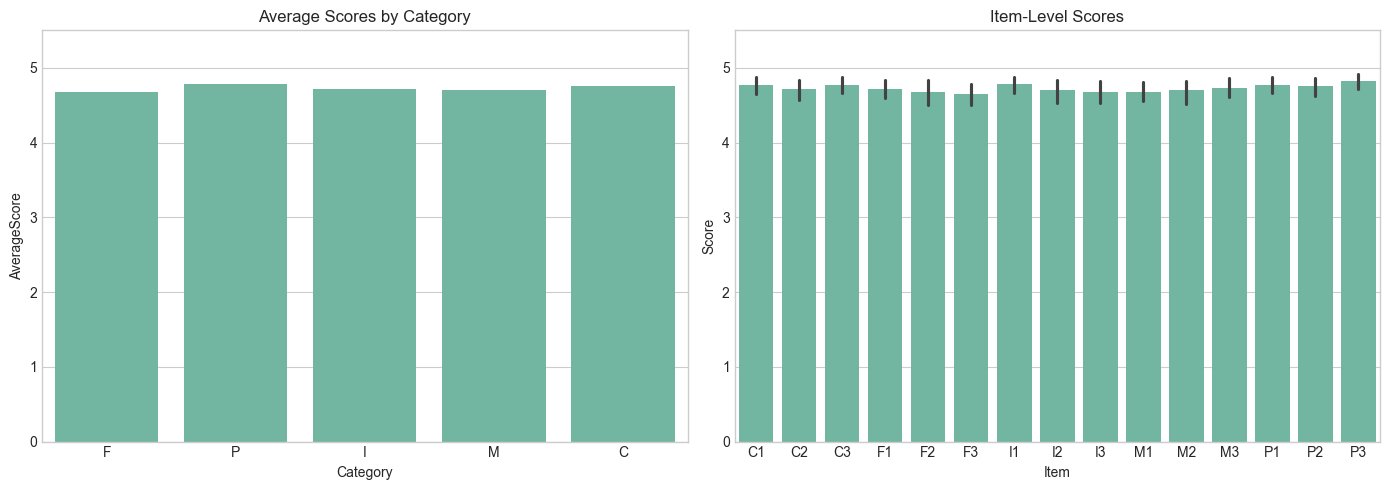

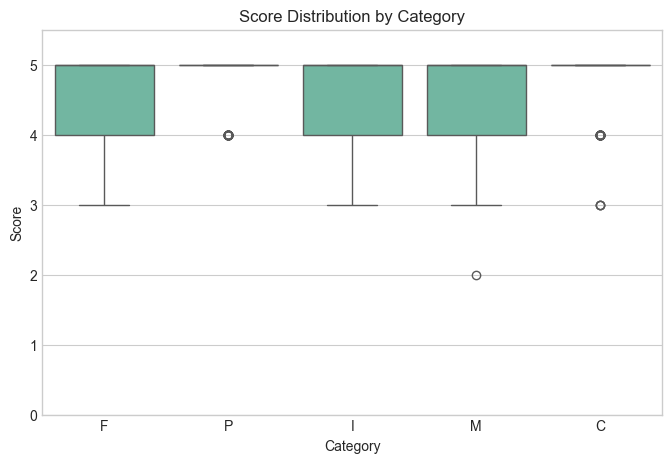

In [21]:
# Rating analysis by dimension
category_avg = (
    pd.DataFrame({cat: df[cols].mean(axis=1) for cat, cols in category_map.items()})
    .mean()
    .reset_index()
    .rename(columns={"index": "Category", 0: "AverageScore"})
)

item_long = df[item_cols].melt(var_name="Item", value_name="Score")
item_long["Category"] = item_long["Item"].str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=category_avg, x="Category", y="AverageScore", ax=axes[0])
axes[0].set_ylim(0, 5.5)
axes[0].set_title("Average Scores by Category")

item_order = sorted(item_long["Item"].unique())
sns.barplot(data=item_long, x="Item", y="Score", order=item_order, ax=axes[1])
axes[1].set_ylim(0, 5.5)
axes[1].set_title("Item-Level Scores")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=item_long, x="Category", y="Score")
plt.title("Score Distribution by Category")
plt.ylim(0, 5.5)
plt.show()

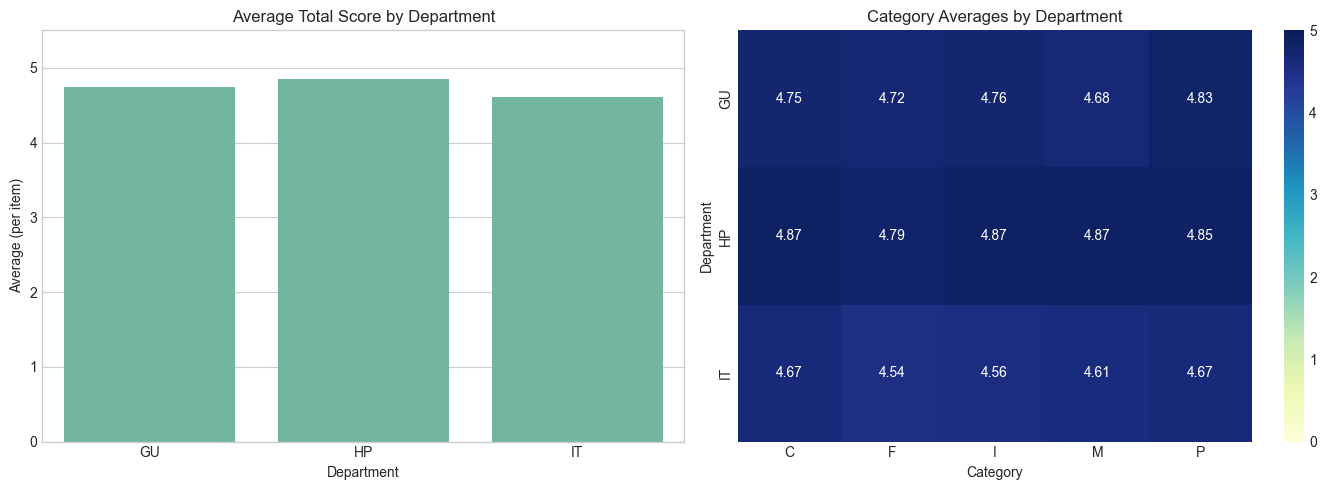

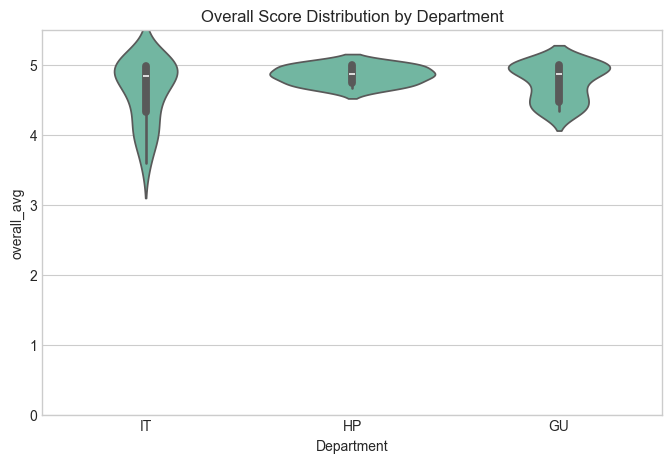

In [22]:
# Cross-group comparisons (departments)
category_avg_by_dept = pd.DataFrame({
    cat: df.groupby("Department")[cols].mean().mean(axis=1) for cat, cols in category_map.items()
})
category_avg_by_dept = category_avg_by_dept.reset_index().melt(
    id_vars="Department", var_name="Category", value_name="AverageScore"
)

dept_totals = df.groupby("Department")["overall_total"].mean().reset_index()
dept_totals["overall_avg"] = dept_totals["overall_total"] / len(item_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=dept_totals, x="Department", y="overall_avg", ax=axes[0])
axes[0].set_title("Average Total Score by Department")
axes[0].set_ylabel("Average (per item)")
axes[0].set_ylim(0, 5.5)

heatmap_data = category_avg_by_dept.pivot(
    index="Department", columns="Category", values="AverageScore"
)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", vmin=0, vmax=5, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Category Averages by Department")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Department", y="overall_avg")
plt.title("Overall Score Distribution by Department")
plt.ylim(0, 5.5)
plt.show()

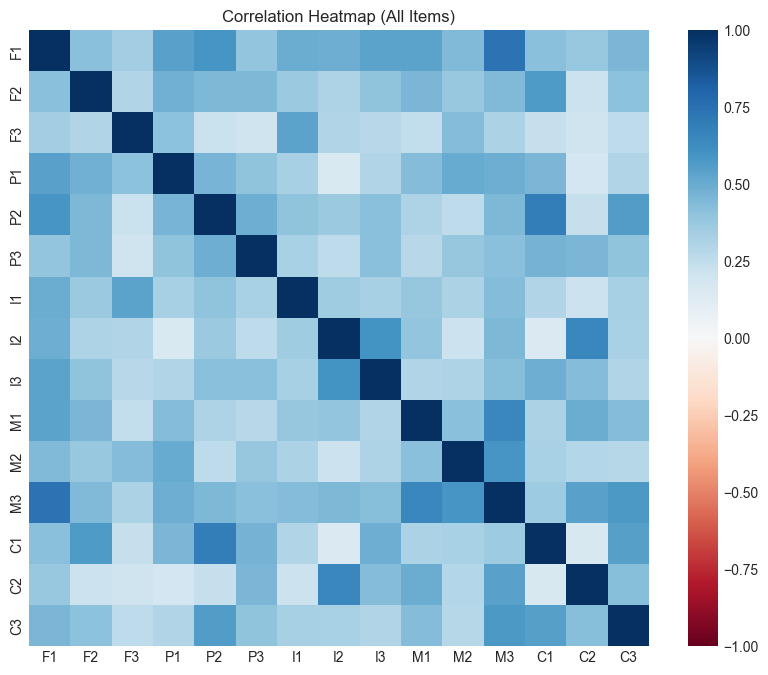

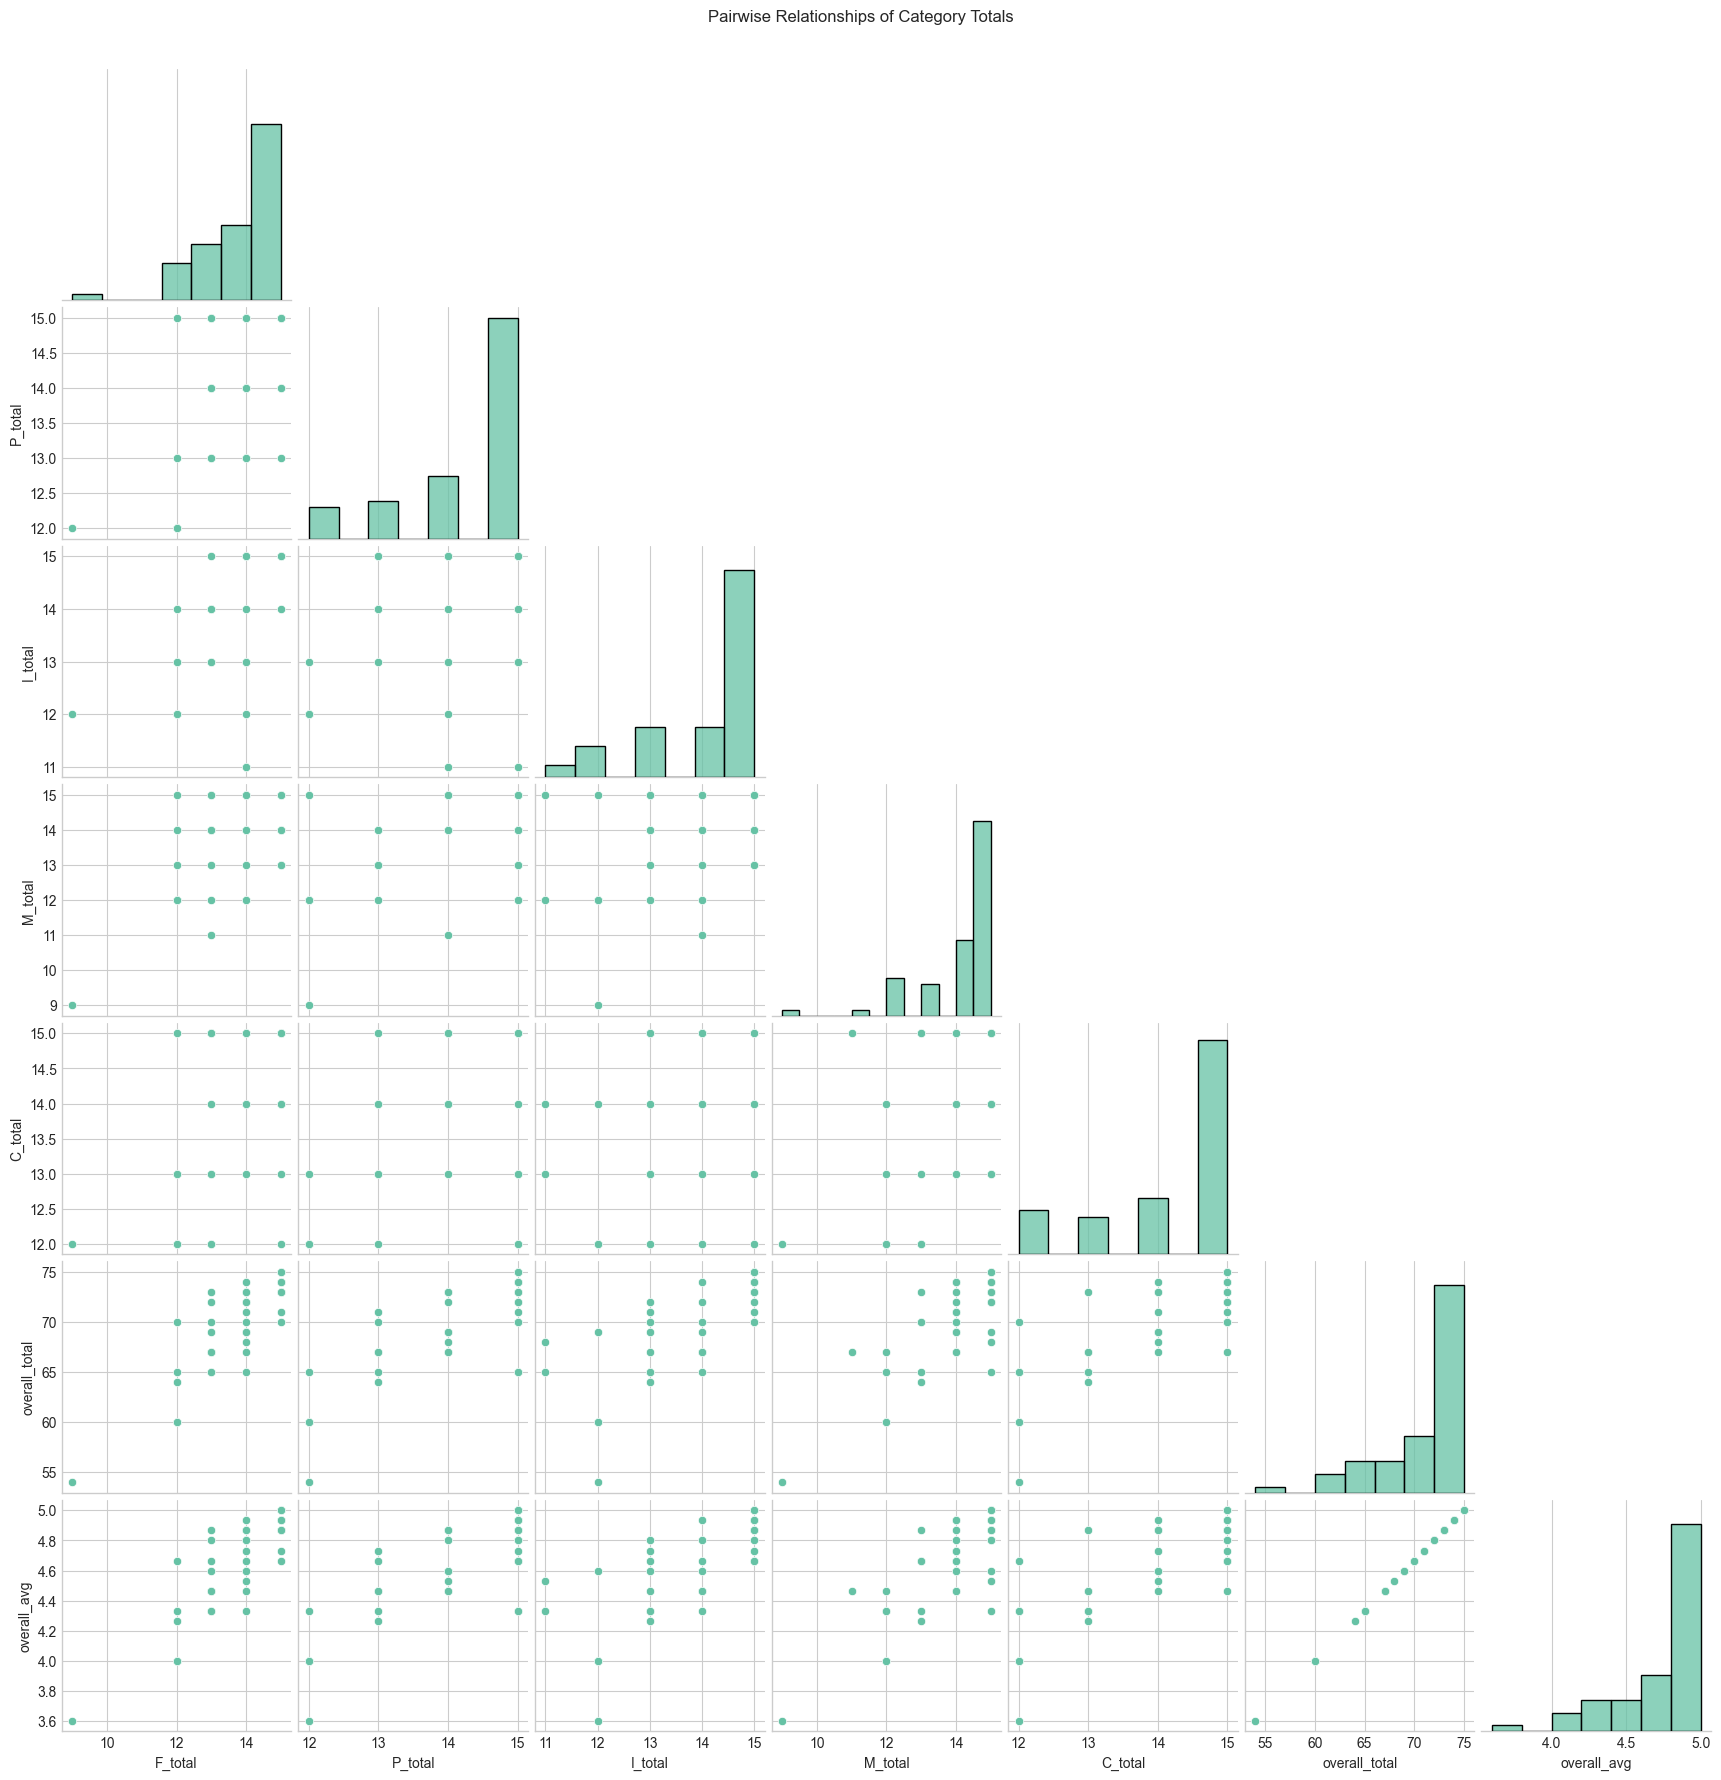

In [23]:
# Correlation and reliability views
corr_items = df[item_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_items, cmap="RdBu", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap (All Items)")
plt.show()

category_totals = df[[f"{cat}_total" for cat in category_map]].copy()
category_totals.columns = [f"{cat}_total" for cat in category_map]
category_totals["overall_total"] = df["overall_total"]
category_totals["overall_avg"] = category_totals["overall_total"] / len(item_cols)

sns.pairplot(category_totals, corner=True)
plt.suptitle("Pairwise Relationships of Category Totals", y=1.02)
plt.show()

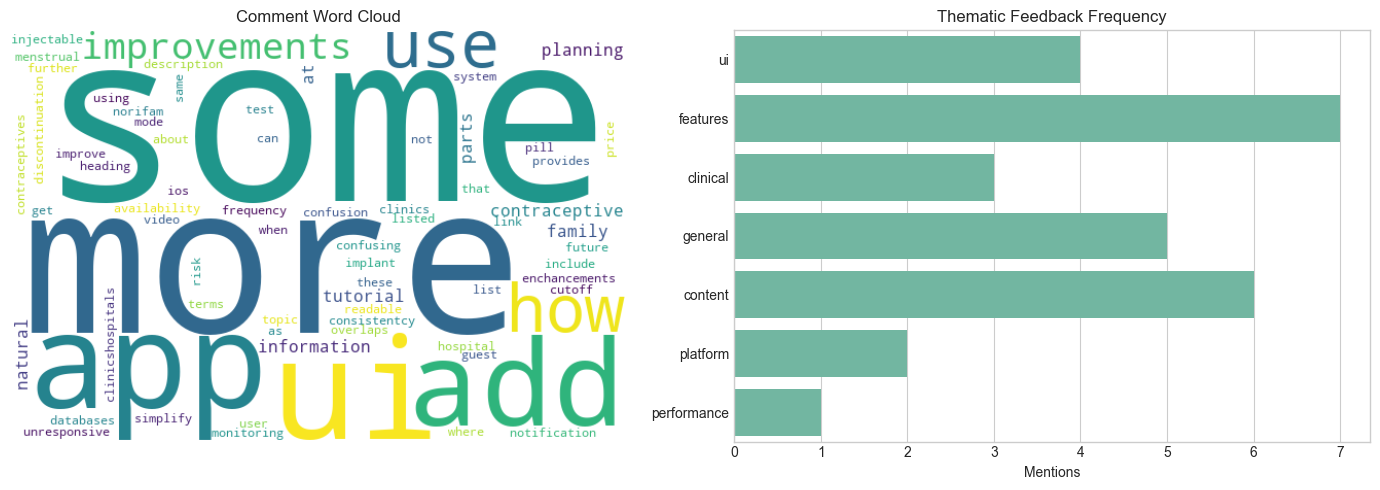

In [24]:
# Text feedback visualization
comments = df["comments_combined"].fillna("").str.lower().str.strip()
comments = comments[comments != ""]

comment_words = (
    comments.str.replace(r"[^a-zA-Z\s]", "", regex=True)
    .str.split()
    .explode()
)
stopwords = {"and", "the", "of", "for", "to", "a", "an", "in", "on", "is", "it", "be"}
comment_words = comment_words[~comment_words.isin(stopwords)]
comment_counts = Counter(comment_words.dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if WORDCLOUD_AVAILABLE and comment_counts:
    wc = WordCloud(width=600, height=400, background_color="white")
    wc.generate_from_frequencies(comment_counts)
    axes[0].imshow(wc, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title("Comment Word Cloud")
else:
    top_terms = comment_counts.most_common(15)
    if top_terms:
        terms, counts = zip(*top_terms)
        sns.barplot(x=list(counts), y=list(terms), ax=axes[0])
        axes[0].set_title("Top Comment Terms")
        axes[0].set_xlabel("Count")
    else:
        axes[0].text(0.5, 0.5, "No comment text", ha="center")
        axes[0].axis("off")

# Simple thematic coding via keyword buckets
theme_keywords = {
    "ui": ["ui", "interface", "design", "readable"],
    "performance": ["slow", "lag", "unresponsive"],
    "features": ["feature", "add", "notification", "link", "price", "list"],
    "content": ["info", "information", "description", "tutorial", "video", "education"],
    "platform": ["ios", "availability", "guest"],
    "clinical": ["clinic", "hospital", "implant"]
}

def tag_themes(text: str) -> list[str]:
    tags = []
    for theme, keys in theme_keywords.items():
        if any(k in text for k in keys):
            tags.append(theme)
    return tags or ["general"]

all_tags = list(chain.from_iterable(tag_themes(t) for t in comments))
theme_counts = Counter(all_tags)

sns.barplot(
    x=list(theme_counts.values()),
    y=list(theme_counts.keys()),
    ax=axes[1]
)
axes[1].set_title("Thematic Feedback Frequency")
axes[1].set_xlabel("Mentions")
plt.tight_layout()
plt.show()